Repeat,0,1,2,3,4,5,6,7,8,9
RMSE,50.965694,52.647545,53.093355,54.220864,54.27268,54.30241,55.221379,55.295671,57.967747,60.477647


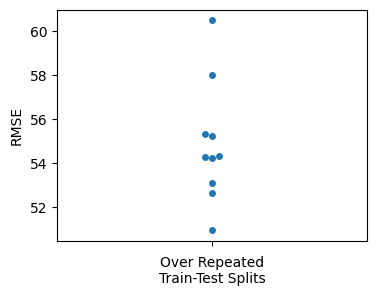

In [ ]:
from sklearn import datasets, metrics, model_selection as skms
from sklearn import linear_model
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()
scores = []
for r in range(10):
  tts = skms.train_test_split(diabetes.data,
    diabetes.target,
    test_size=.25)
  (diabetes_train_ftrs, diabetes_test_ftrs,
      diabetes_train_tgt, diabetes_test_tgt) = tts
  fit = linreg.fit(diabetes_train_ftrs, diabetes_train_tgt)
  preds = fit.predict(diabetes_test_ftrs)
  score = metrics.mean_squared_error(diabetes_test_tgt, preds)
  scores.append(score)
scores = pd.Series(np.sqrt(sorted(scores)))
df = pd.DataFrame({'RMSE':scores})
df.index.name = 'Repeat'
display(df.T)
ax = plt.figure(figsize=(4, 3)).gca()
sns.swarmplot(y='RMSE', data=df, ax=ax)
ax.set_xlabel('Over Repeated\nTrain-Test Splits');